# Identificación automática de fenómenos físicos mediante Machine Learning

## Objetivo

En muchos experimentos físicos se obtienen grandes cantidades de datos
en forma de trayectorias temporales. Identificar el fenómeno físico que
generó una trayectoria puede requerir análisis manual y ajuste de modelos.

En este proyecto se desarrolla un modelo de Machine Learning capaz de
clasificar automáticamente diferentes tipos de movimiento físico a partir
de trayectorias sintéticas afectadas por ruido experimental.

Los fenómenos considerados son:

- Movimiento uniforme
- Movimiento uniformemente acelerado
- Movimiento oscilatorio

El objetivo es evaluar si algoritmos de aprendizaje automático pueden
recuperar información física a partir de datos ruidosos.

**Librerías a utilizar**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import seaborn as sns

np.random.seed(42)

### 1. Simulación de trayectorias
Vamos a crear simulaciones de tres tipos de movientos cuyos parametros se generaran aleatoriamente, para posteriormente agregar ruido gaussiano. <br> 
Primero creamos el eje temporal:

In [2]:
t = np.linspace(0,10,100)

**Movimiento uniforme**

In [3]:
def movimiento_uniforme(t):
    
    x0 = np.random.uniform(-5,5)
    v = np.random.uniform(1,5)
    
    x = x0 + v*t
    
    return x

**Movimiento acelerado**

In [4]:
def movimiento_acelerado(t):
    
    x0 = np.random.uniform(-5,5)
    v0 = np.random.uniform(0,3)
    a = np.random.uniform(0.5,2)
    
    x = x0 + v0*t + 0.5*a*t**2
    
    return x

**Movimiento oscilatorio**

In [5]:
def movimiento_oscilatorio(t):
    
    A = np.random.uniform(1,5)
    w = np.random.uniform(1,3)
    phi = np.random.uniform(0,2*np.pi)
    
    x = A*np.sin(w*t + phi)
    
    return x

**Función para agregar ruido**

In [6]:
def agregar_ruido(x, sigma=0.5):
    # Podemos modificar sigma para aumentar o disminuir el ruido
    ruido = np.random.normal(
        loc=0,
        scale=sigma,
        size=len(x)
    )
    
    return x + ruido

Creamos ahora nuestro dataset a partir de estas funciones, la idea es que cada fila represente una trayectoria completa, construiremos 500 trayectorias de cada tipo de movimiento. <br>

In [7]:
def generar_dataset_experimental(n_muestras=500, sigma=0.5):

    datos = []
    etiquetas = []

    id_trayectoria = 0


    movimientos = [
        (movimiento_uniforme, 0),
        (movimiento_acelerado, 1),
        (movimiento_oscilatorio, 2)
    ]


    for i in range(n_muestras):

        for funcion, etiqueta in movimientos:

            posicion = funcion(t)
            posicion = agregar_ruido(posicion, sigma)

            for tiempo, pos in zip(t, posicion):

                datos.append(
                    [
                        id_trayectoria,
                        tiempo,
                        pos
                    ]
                )

            etiquetas.append(
                [
                    id_trayectoria,
                    etiqueta
                ]
            )

            id_trayectoria += 1


    df_datos = pd.DataFrame(
        datos,
        columns=[
            "id",
            "tiempo",
            "posicion"
        ]
    )


    df_labels = pd.DataFrame(
        etiquetas,
        columns=[
            "id",
            "tipo_movimiento"
        ]
    )


    return df_datos, df_labels

df_datos, df_labels = generar_dataset_experimental()

df_ datos contiene unicamente a informacion de las 1500 trayectorias, donde:<br>
id: identificador del numero de trayectoria<br>
tiempo: variable de tiempo <br>
posicion: variable de posicion <br><br>
df_labels: contiene la relacion entre la trayectoria (id) y el tipo de movimiento que es:<br>
0 → uniforme<br>
1 → acelerado<br>
2 → oscilatorio<br>
Si los datos fueran obtenidos experimentalente, no conoceriamos esta información, pero aqui la guardamos para comparar con el modelo ML.

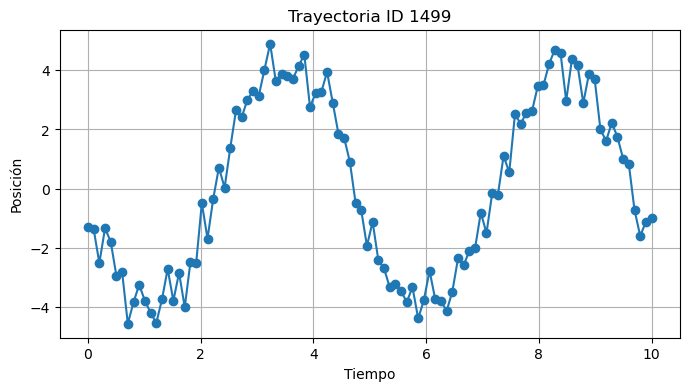

In [8]:
# Visualización de una trayectoria individual
id_seleccionado = 1499

trayectoria = df_datos[df_datos["id"] == id_seleccionado]

plt.figure(figsize=(8,4))

plt.plot(
    trayectoria["tiempo"],
    trayectoria["posicion"],
    marker="o"
)

plt.xlabel("Tiempo")
plt.ylabel("Posición")
plt.title(f"Trayectoria ID {id_seleccionado}")

plt.grid()
plt.show()

### 2. Extracción de características físicas

Una trayectoria experimental está representada por la posición de un objeto en función del tiempo:

$$x(t)$$

Sin embargo, utilizar directamente todos los puntos de la trayectoria como entrada para un modelo de Machine Learning puede ocultar propiedades físicas relevantes y dificultar la interpretación del modelo.

Por esta razón, se realiza una etapa de extracción de características basada en cantidades cinemáticas.

A partir de la posición se calculan:

$$
v(t)=\frac{dx}{dt}
$$

$$
a(t)=\frac{d^2x}{dt^2}
$$

donde $v(t)$ representa la velocidad instantánea y \(a(t)\) la aceleración.

Las características seleccionadas buscan capturar diferentes comportamientos dinámicos:

### Velocidad

- **Velocidad media:** representa la tendencia general del desplazamiento.
- **Velocidad máxima y mínima:** permiten identificar cambios extremos y distinguir movimientos con inversión de dirección, como los movimientos oscilatorios.
- **Desviación estándar de la velocidad:** mide qué tan constante es la dinámica del movimiento. Un movimiento uniforme presenta poca variabilidad, mientras que movimientos acelerados u oscilatorios presentan mayor dispersión.

### Aceleración

- **Aceleración media:** permite identificar la presencia de una aceleración neta, característica de movimientos uniformemente acelerados.
- **Desviación estándar de la aceleración:** permite diferenciar entre una aceleración aproximadamente constante y comportamientos donde la aceleración cambia continuamente, como en movimientos oscilatorios.

Estas características proporcionan una representación compacta de la dinámica del sistema manteniendo una interpretación física directa.

In [9]:
def extraer_caracteristicas(trayectoria):
    
    # Calcular velocidad numérica
    velocidad = np.gradient(
        trayectoria["posicion"],
        trayectoria["tiempo"]
    )
    
    # Calcular aceleración numérica
    aceleracion = np.gradient(
        velocidad,
        trayectoria["tiempo"]
    )
    
    
    caracteristicas = {
        
        "velocidad_media": np.mean(velocidad),
        
        "velocidad_max": np.max(velocidad),
        
        "velocidad_min": np.min(velocidad),
        
        "std_velocidad": np.std(velocidad),
        
        "aceleracion_media": np.mean(aceleracion),
        
        "std_aceleracion": np.std(aceleracion)
        
    }
    
    return caracteristicas

Vamos a extraer las caracteristicas de cada trayectoria simulada:

In [10]:
caracteristicas_lista = []

for id_trayectoria in df_datos["id"].unique():
    
    # Seleccionamos una trayectoria
    trayectoria = df_datos[
        df_datos["id"] == id_trayectoria
    ]
    
    # Extraemos características físicas
    caracteristicas = extraer_caracteristicas(
        trayectoria
    )
    
    # Guardamos el identificador
    caracteristicas["id"] = id_trayectoria
    
    caracteristicas_lista.append(
        caracteristicas
    )

df_features = pd.DataFrame(caracteristicas_lista)

construimos nuestro dataset completo, agregando el tipo de movimiento

In [11]:
df_ml = df_features.merge(df_labels, on="id")

df_ml.head()

,velocidad_media,velocidad_max,velocidad_min,std_velocidad,aceleracion_media,std_aceleracion,id,tipo_movimiento
0,4.796259,11.502168,-2.399366,3.282081,0.002514,29.065606,0,0
1,10.452877,23.710766,-9.964876,6.604647,2.939019,30.637253,1,1
2,-0.159885,13.000083,-13.914940,5.845875,-0.209823,32.534228,2,2
3,1.664337,7.896450,-6.474017,3.018548,0.963053,26.738532,3,0
4,11.046054,26.785202,-3.277682,6.387986,2.423961,32.474981,4,1


### 3. Modelo de aprendizaje

In [12]:
modelo = RandomForestClassifier(n_estimators=100,random_state=42)

El modelo a entrenar sera *RandomForestClassifier*: es un algoritmo de aprendizaje supervisado que combina múltiples árboles de decisión para realizar una predicción final mediante un proceso de votación.<br>

Este modelo fue seleccionado debido a que: <br><br>

- Puede trabajar con relaciones no lineales entre las características.
- Es robusto ante variaciones y ruido en los datos.
- Funciona correctamente con conjuntos de datos pequeños o medianos.
- Permite interpretar la importancia relativa de las variables utilizadas.<br><br>

En este proyecto, el modelo busca aprender la relación entre las características cinemáticas de una trayectoria:

$$
X =
(v_{media},v_{max},v_{min},\sigma_v,a_{media},\sigma_a)
$$

y la clase del fenómeno físico:

$$
y =
\{uniforme, acelerado, oscilatorio\}
$$

Primero apartamos los datos a trabajar:

In [13]:
X = df_ml.drop(
    columns=[
        "id",
        "tipo_movimiento"
    ]
)

y = df_ml["tipo_movimiento"]

Seleccionamos un porcentaje para entrenar y el resto para comparar. (60-40 en este caso)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.6,
    random_state=42,
    stratify=y
)

Enseñamos al modelo

In [15]:
modelo.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

Hacemos predicciones:

In [16]:
y_pred = modelo.predict(
    X_test
)

### Evaluación del desempeño del modelo

Después del entrenamiento, el modelo es evaluado utilizando datos que no fueron utilizados durante el aprendizaje.

Se comparan las etiquetas reales del conjunto de prueba:

$$
y_{test}
$$

contra las predicciones realizadas por el modelo:

$$
\hat{y}
$$

La métrica inicial utilizada es la exactitud (*accuracy*), que representa la proporción de trayectorias clasificadas correctamente.

$$
Accuracy=
\frac{\text{número de predicciones correctas}}
{\text{número total de predicciones}}
$$

Esta métrica proporciona una visión general del desempeño del clasificador.

In [17]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9622222222222222


Otra metrica a utilizar es la matriz de confusión: 

La matriz de confusión permite analizar el desempeño del clasificador para cada clase individualmente.

Las filas representan la clase real del fenómeno físico y las columnas representan la predicción realizada por el modelo.

Una clasificación perfecta tendría todos los valores concentrados en la diagonal principal, indicando que cada trayectoria fue asignada correctamente.

Los elementos fuera de la diagonal representan errores de clasificación y permiten identificar qué fenómenos presentan comportamientos similares desde la perspectiva del modelo.

In [18]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[297,   1,   2],
       [ 31, 269,   0],
       [  0,   0, 300]], dtype=int64)

### Conclusiones

En este proyecto se desarrolló un pipeline de aprendizaje automático para la identificación automática de fenómenos físicos a partir de trayectorias posición-tiempo.

Se generaron datos sintéticos con estructura equivalente a mediciones experimentales, incorporando ruido para simular incertidumbre en la adquisición.

Posteriormente se extrajeron características estadísticas de velocidad y aceleración, buscando representar propiedades físicas relevantes de cada dinámica.

Estas características fueron utilizadas como entrada para un modelo Random Forest encargado de clasificar tres tipos de movimiento:

- Movimiento uniforme.
- Movimiento acelerado.
- Movimiento oscilatorio.

El modelo alcanzó una exactitud del 96.2% utilizando una separación 60%-40% entre entrenamiento y prueba. Además, la matriz de confusión mostró que la mayoría de las trayectorias fueron clasificadas correctamente, con valores concentrados en la diagonal principal.

Los resultados muestran que una representación adecuada basada en propiedades físicas permite identificar automáticamente diferentes dinámicas a partir de datos experimentales.

Este enfoque puede extenderse hacia datos reales provenientes de sensores, experimentos de laboratorio o sistemas físicos más complejos.

### Trabajo futuro

Algunas extensiones naturales de este proyecto serían:

- Aplicar el modelo a datos experimentales reales obtenidos mediante sensores.
- Incorporar modelos capaces de analizar trayectorias más complejas.
- Estudiar sistemas donde la dinámica física no sea conocida previamente.
- Comparar modelos clásicos de Machine Learning con redes neuronales para clasificación de series temporales.
- Introducir métodos de detección de anomalías en trayectorias experimentales.